# 26 -- D (hyperbolic) RBM: energy function + CD-1 training

Core idea: under the idempotent decomposition z = e_plus*e_+ + e_minus*e_-, a D-valued RBM splits into **two independent real-valued RBMs**, one running on the e_plus channel and one on e_minus, each trained with standard CD-1 -- no special hyperbolic gradient descent needed. The two channels are combined only at read-out time (a_pred = e_plus_pred + e_minus_pred).

Uses `train_hyperbolic.csv` / `test_hyperbolic.csv` from notebook 25's Phase 4 (userId, movieId, rating, timestamp, a, b, e_plus, e_minus).

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
data_dir = root / "data"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

torch.manual_seed(42)

train_hyp = pd.read_csv(data_dir / "train_hyperbolic.csv")
test_hyp = pd.read_csv(data_dir / "test_hyperbolic.csv")
print(f"train_hyperbolic: {len(train_hyp):,} rows   test_hyperbolic: {len(test_hyp):,} rows")

all_users = sorted(pd.concat([train_hyp["userId"], test_hyp["userId"]]).unique())
all_movies = sorted(pd.concat([train_hyp["movieId"], test_hyp["movieId"]]).unique())
n_users, n_movies = len(all_users), len(all_movies)
user_to_row = {u: i for i, u in enumerate(all_users)}
movie_to_col = {m: j for j, m in enumerate(all_movies)}
print(f"n_users={n_users}  n_movies={n_movies}")

train_hyperbolic: 492,055 rows   test_hyperbolic: 123,474 rows
n_users=1000  n_movies=1000


## Step 1 -- a standard real-valued RBM (PyTorch)

Manual CD-1 (no autograd -- PyTorch is used here purely as a fast tensor library, matching the classic contrastive-divergence update rule already used throughout this project):

$$h\_prob = \sigma(vW + b_h) \qquad v\_prob = \sigma(hW^T + b_v) \qquad \Delta W = \eta\,(\langle v h\rangle_{data} - \langle v h\rangle_{recon})$$

Missing ratings (NaN, i.e. unrated movies) are zero-filled in `v` and excluded from the gradient and the loss via a `mask` -- same convention as the masked CD-1 training used everywhere else in this project (notebooks 13b/17/19/22).

In [2]:
class RBM:
    def __init__(self, n_visible, n_hidden, seed=42, device="cpu"):
        g = torch.Generator(device=device).manual_seed(seed)
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.device = device
        self.W = (torch.randn(n_visible, n_hidden, generator=g, device=device) * 0.01)
        self.vbias = torch.zeros(n_visible, device=device)
        self.hbias = torch.zeros(n_hidden, device=device)

    def sample_h(self, v):
        h_prob = torch.sigmoid(v @ self.W + self.hbias)
        h_sample = torch.bernoulli(h_prob)
        return h_prob, h_sample

    def sample_v(self, h):
        return torch.sigmoid(h @ self.W.t() + self.vbias)

    def reconstruct(self, v, mask=None):
        """Deterministic (mean-field) forward+backward pass -- used for prediction, not training."""
        h_prob = torch.sigmoid(v @ self.W + self.hbias)
        v_prob = torch.sigmoid(h_prob @ self.W.t() + self.vbias)
        if mask is not None:
            v_prob = v_prob * mask
        return v_prob

    def cd1_step(self, v0, mask, lr):
        bs = v0.shape[0]
        h0_prob, h0_sample = self.sample_h(v0)
        v1_prob = self.sample_v(h0_sample) * mask
        h1_prob, _ = self.sample_h(v1_prob)

        pos = v0.t() @ h0_prob
        neg = v1_prob.t() @ h1_prob
        self.W += lr * (pos - neg) / bs
        self.vbias += lr * (v0 - v1_prob).sum(dim=0) / bs
        self.hbias += lr * (h0_prob - h1_prob).sum(dim=0) / bs

        n_obs = mask.sum().clamp(min=1)
        mse = (((v0 - v1_prob) ** 2) * mask).sum() / n_obs
        return mse.item()

    def train(self, v_full, mask_full, batch_size, epochs, lr, seed=42, verbose=True):
        n = v_full.shape[0]
        g = torch.Generator().manual_seed(seed)
        history = []
        for epoch in range(epochs):
            order = torch.randperm(n, generator=g)
            epoch_mse, n_batches = 0.0, 0
            for start in range(0, n, batch_size):
                idx = order[start:start + batch_size]
                mse = self.cd1_step(v_full[idx], mask_full[idx], lr)
                epoch_mse += mse
                n_batches += 1
            epoch_mse /= n_batches
            history.append(epoch_mse)
            if verbose and (epoch + 1) % 5 == 0:
                print(f"  epoch {epoch + 1:3d}/{epochs}: reconstruction MSE (masked) = {epoch_mse:.5f}")
        return history

## Step 2 -- D-RBM = two parallel RBMs

`RBM_plus` trains on the `e_plus` column, `RBM_minus` on `e_minus` -- each built into its own (n_users x n_movies) matrix, **train-set values only** (test positions stay masked out, exactly like held-out ratings should be during training).

In [3]:
def build_matrix(df, value_col):
    mat = torch.zeros(n_users, n_movies, dtype=torch.float32)
    mask = torch.zeros(n_users, n_movies, dtype=torch.float32)
    rows = torch.tensor(df["userId"].map(user_to_row).values, dtype=torch.long)
    cols = torch.tensor(df["movieId"].map(movie_to_col).values, dtype=torch.long)
    vals = torch.tensor(df[value_col].values, dtype=torch.float32)
    mat[rows, cols] = vals
    mask[rows, cols] = 1.0
    return mat, mask

v_plus_train, mask_train = build_matrix(train_hyp, "e_plus")
v_minus_train, _ = build_matrix(train_hyp, "e_minus")  # same mask (same rated positions)

print(f"v_plus_train:  shape={tuple(v_plus_train.shape)}  observed cells={int(mask_train.sum())}")
print(f"v_minus_train: shape={tuple(v_minus_train.shape)}")
print(f"density: {mask_train.mean().item():.4f}")

v_plus_train:  shape=(1000, 1000)  observed cells=492055
v_minus_train: shape=(1000, 1000)
density: 0.4921


## Step 3 -- train both RBMs with CD-1

In [4]:
N_HIDDEN = 128
BATCH_SIZE = 100   # users
EPOCHS = 50
LR = 0.05

print("training RBM_plus (e_plus channel)...")
rbm_plus = RBM(n_visible=n_movies, n_hidden=N_HIDDEN, seed=42)
history_plus = rbm_plus.train(v_plus_train, mask_train, BATCH_SIZE, EPOCHS, LR, seed=42)

print()
print("training RBM_minus (e_minus channel)...")
rbm_minus = RBM(n_visible=n_movies, n_hidden=N_HIDDEN, seed=43)
history_minus = rbm_minus.train(v_minus_train, mask_train, BATCH_SIZE, EPOCHS, LR, seed=43)

print()
print(f"final MSE -- RBM_plus: {history_plus[-1]:.5f}   RBM_minus: {history_minus[-1]:.5f}")

training RBM_plus (e_plus channel)...
  epoch   5/50: reconstruction MSE (masked) = 0.01302
  epoch  10/50: reconstruction MSE (masked) = 0.01331
  epoch  15/50: reconstruction MSE (masked) = 0.01318


  epoch  20/50: reconstruction MSE (masked) = 0.01290


  epoch  25/50: reconstruction MSE (masked) = 0.01266


  epoch  30/50: reconstruction MSE (masked) = 0.01246
  epoch  35/50: reconstruction MSE (masked) = 0.01230
  epoch  40/50: reconstruction MSE (masked) = 0.01221
  epoch  45/50: reconstruction MSE (masked) = 0.01214


  epoch  50/50: reconstruction MSE (masked) = 0.01206

training RBM_minus (e_minus channel)...


  epoch   5/50: reconstruction MSE (masked) = 0.01590


  epoch  10/50: reconstruction MSE (masked) = 0.01555
  epoch  15/50: reconstruction MSE (masked) = 0.01432
  epoch  20/50: reconstruction MSE (masked) = 0.01338
  epoch  25/50: reconstruction MSE (masked) = 0.01278


  epoch  30/50: reconstruction MSE (masked) = 0.01243


  epoch  35/50: reconstruction MSE (masked) = 0.01211


  epoch  40/50: reconstruction MSE (masked) = 0.01195
  epoch  45/50: reconstruction MSE (masked) = 0.01187
  epoch  50/50: reconstruction MSE (masked) = 0.01180

final MSE -- RBM_plus: 0.01206   RBM_minus: 0.01180


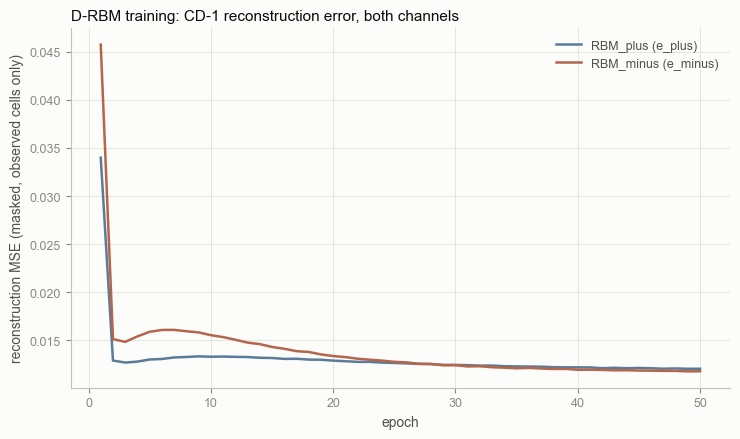

In [5]:
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

fig, ax = plt.subplots(figsize=(7.5, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(range(1, EPOCHS + 1), history_plus, color="#5b7c99", linewidth=1.8, label="RBM_plus (e_plus)", zorder=3)
ax.plot(range(1, EPOCHS + 1), history_minus, color="#b4654a", linewidth=1.8, label="RBM_minus (e_minus)", zorder=3)
ax.set_xlabel("epoch", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("reconstruction MSE (masked, observed cells only)", color=INK_SECONDARY, fontsize=10)
ax.set_title("D-RBM training: CD-1 reconstruction error, both channels", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="best", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / "dRBM_training_loss.png", dpi=150, facecolor=SURFACE)
plt.show()

## Step 4 -- predict on test set, evaluate

For every test row: reconstruct that user's full e_plus/e_minus vector from their **train-only** ratings (deterministic mean-field pass), read off the value at the held-out movie, recombine `a_pred = e_plus_pred + e_minus_pred` (exact by construction of the idempotent decomposition), then invert the min-max normalization back to the 0.5-5.0 rating scale.

In [6]:
with torch.no_grad():
    v_plus_recon = rbm_plus.reconstruct(v_plus_train)     # (n_users, n_movies), full mean-field reconstruction
    v_minus_recon = rbm_minus.reconstruct(v_minus_train)

test_rows = torch.tensor(test_hyp["userId"].map(user_to_row).values, dtype=torch.long)
test_cols = torch.tensor(test_hyp["movieId"].map(movie_to_col).values, dtype=torch.long)

e_plus_pred = v_plus_recon[test_rows, test_cols].numpy()
e_minus_pred = v_minus_recon[test_rows, test_cols].numpy()

a_pred = e_plus_pred + e_minus_pred
rating_pred = np.clip(a_pred * 4.5 + 0.5, 0.5, 5.0)
rating_true = test_hyp["rating"].values

rmse = float(np.sqrt(np.mean((rating_pred - rating_true) ** 2)))
mae = float(np.mean(np.abs(rating_pred - rating_true)))

print(f"test set (n={len(test_hyp):,}):")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")

test set (n=123,474):
  RMSE: 0.9523
  MAE:  0.7187


## Step 5 -- save trained weights

In [7]:
np.save(data_dir / "W_plus_drbm.npy", rbm_plus.W.numpy())
np.save(data_dir / "hbias_plus_drbm.npy", rbm_plus.hbias.numpy())
np.save(data_dir / "vbias_plus_drbm.npy", rbm_plus.vbias.numpy())

np.save(data_dir / "W_minus_drbm.npy", rbm_minus.W.numpy())
np.save(data_dir / "hbias_minus_drbm.npy", rbm_minus.hbias.numpy())
np.save(data_dir / "vbias_minus_drbm.npy", rbm_minus.vbias.numpy())

print("saved: W_plus_drbm.npy, hbias_plus_drbm.npy, vbias_plus_drbm.npy")
print("saved: W_minus_drbm.npy, hbias_minus_drbm.npy, vbias_minus_drbm.npy")
print(f"W_plus shape:  {rbm_plus.W.shape}")
print(f"W_minus shape: {rbm_minus.W.shape}")

saved: W_plus_drbm.npy, hbias_plus_drbm.npy, vbias_plus_drbm.npy
saved: W_minus_drbm.npy, hbias_minus_drbm.npy, vbias_minus_drbm.npy
W_plus shape:  torch.Size([1000, 128])
W_minus shape: torch.Size([1000, 128])


## Step 6 -- R (real) baseline RBM, identical architecture/hyperparameters

Same `RBM` class, same H=128 / batch=100 (users) / 50 epochs / lr=0.05, same masked-CD-1, trained on a single real-valued channel: the min-max normalized rating itself (the `a` column from notebook 25 Phase 4, (rating-0.5)/4.5) -- not the D decomposition. Direct comparison baseline against RBM_plus/RBM_minus above.

In [8]:
v_real_train, _ = build_matrix(train_hyp, "a")   # same mask_train (same rated positions as e_plus/e_minus)

print("training RBM_real (baseline)...")
rbm_real = RBM(n_visible=n_movies, n_hidden=N_HIDDEN, seed=44)
history_real = rbm_real.train(v_real_train, mask_train, BATCH_SIZE, EPOCHS, LR, seed=44)
print(f"final MSE -- RBM_real: {history_real[-1]:.5f}")

training RBM_real (baseline)...
  epoch   5/50: reconstruction MSE (masked) = 0.03876
  epoch  10/50: reconstruction MSE (masked) = 0.03866
  epoch  15/50: reconstruction MSE (masked) = 0.03848
  epoch  20/50: reconstruction MSE (masked) = 0.03763


  epoch  25/50: reconstruction MSE (masked) = 0.03701


  epoch  30/50: reconstruction MSE (masked) = 0.03676
  epoch  35/50: reconstruction MSE (masked) = 0.03633
  epoch  40/50: reconstruction MSE (masked) = 0.03622
  epoch  45/50: reconstruction MSE (masked) = 0.03593
  epoch  50/50: reconstruction MSE (masked) = 0.03563
final MSE -- RBM_real: 0.03563


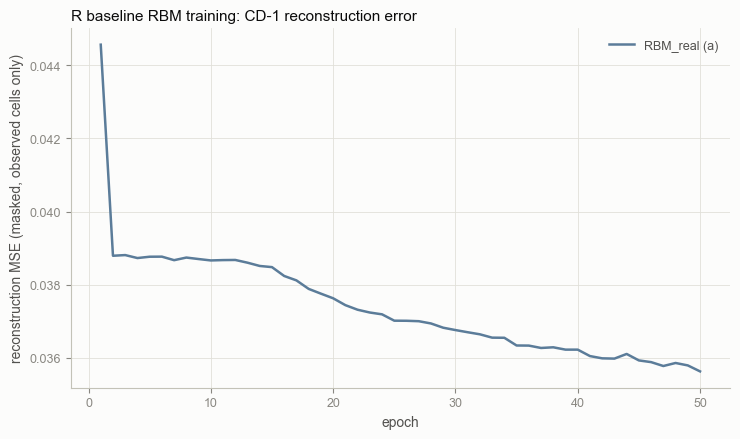

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(range(1, EPOCHS + 1), history_real, color="#5b7c99", linewidth=1.8, label="RBM_real (a)", zorder=3)
ax.set_xlabel("epoch", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("reconstruction MSE (masked, observed cells only)", color=INK_SECONDARY, fontsize=10)
ax.set_title("R baseline RBM training: CD-1 reconstruction error", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="best", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / "realRBM_training_loss.png", dpi=150, facecolor=SURFACE)
plt.show()

##### Predict + evaluate, compare against D-RBM

In [10]:
with torch.no_grad():
    v_real_recon = rbm_real.reconstruct(v_real_train)

a_pred_real = v_real_recon[test_rows, test_cols].numpy()
rating_pred_real = np.clip(a_pred_real * 4.5 + 0.5, 0.5, 5.0)

rmse_real = float(np.sqrt(np.mean((rating_pred_real - rating_true) ** 2)))
mae_real = float(np.mean(np.abs(rating_pred_real - rating_true)))

print(f"test set (n={len(test_hyp):,}):")
print(f"  RMSE: {rmse_real:.4f}")
print(f"  MAE:  {mae_real:.4f}")

print()
print(f"         {'RMSE':>7s}  {'MAE':>7s}")
print(f"R Real:  {rmse_real:>7.4f}  {mae_real:>7.4f}")
print(f"D Hyp:   {rmse:>7.4f}  {mae:>7.4f}")

test set (n=123,474):
  RMSE: 0.8431
  MAE:  0.6481

            RMSE      MAE
R Real:   0.8431   0.6481
D Hyp:    0.9523   0.7187


##### Save R baseline weights

In [11]:
np.save(data_dir / "W_real.npy", rbm_real.W.numpy())
np.save(data_dir / "hbias_real.npy", rbm_real.hbias.numpy())
np.save(data_dir / "vbias_real.npy", rbm_real.vbias.numpy())
print("saved: W_real.npy, hbias_real.npy, vbias_real.npy")
print(f"W_real shape: {rbm_real.W.shape}")

saved: W_real.npy, hbias_real.npy, vbias_real.npy
W_real shape: torch.Size([1000, 128])
